# Analyze uncertainty after Loop 2

Loads the pure-cell-type solutions, reads the annotation config, collects optimized samples, and checks histograms/heatmaps of the resulting uncertainty.

In [37]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample

## Load solutions 

In [38]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                # uncertainty_path = (
                #     exp_folder
                #     / "uncertainty_annotation"
                #     / "candidates_with_uncertainties.csv"
                # )

                uncertainty_path = (
                    exp_folder
                    / "candidates.csv"
                )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():
 
                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [39]:
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "../../../../../../inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Collect optimized samples 

In [40]:
path_to_results_loop1 = Path("../../../../../../project_folder/output/inverse/loss_guidance/bloodplus_inverse_fm_official/")
paths_loop1 = os.listdir(path_to_results_loop1)

# path_to_results_loop2 = Path("../../../../../../project_folder/output/inverse/loss_guidance/loop2p5_replicate")
# path_to_results_loop2 = Path("../../../../../../project_folder/output/inverse/loss_guidance/loop2p5_replicate_old_clf")
path_to_results_loop2 = Path("../../../../../../project_folder/output/inverse/loss_guidance/bloodplus_inverse_fm_official")
paths_loop2 = os.listdir(path_to_results_loop2)

In [41]:
cell_types = ["late_MgkPro"]

In [42]:
raw_solutions_loop1 = load_pure_cell_type_solutions(
    path_to_results_loop1,
    paths_loop1,
    cell_types,
)

raw_solutions_loop2 = load_pure_cell_type_solutions(
    path_to_results_loop2,
    paths_loop2,
    cell_types,
)

100%|██████████| 6/6 [00:04<00:00,  1.42it/s]


In [43]:
raw_solutions_loop1 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop1.items()
}

raw_solutions_loop2 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop2.items()
}

In [44]:
mgkpro_loop1 = raw_solutions_loop1["late_MgkPro"]
mgkpro_loop2 = raw_solutions_loop2["late_MgkPro"]
# mgkpro_loop1 = mgkpro_loop1.sample(n=mgkpro_loop2.shape[0])

# erypro_loop1 = raw_solutions_loop1["EryPro"]
# erypro_loop2 = raw_solutions_loop2["EryPro"]

In [45]:
mgkpro_loop1

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,late_MgkPro:2026-04-21_16-11-15_04173209:0,10.028185,2.239812,679.62024,542.93100,0.001843,13.811527,0.000000,0.675606,0.067173,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,late_MgkPro:2026-04-21_16-11-15_04173209:1,10.170584,2.804203,838.66590,1124.17290,0.000000,47.934883,0.000000,0.132261,0.063359,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,late_MgkPro:2026-04-21_16-11-15_04173209:2,9.332884,2.502338,684.25290,958.07170,0.077955,46.770470,0.000000,0.212369,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,late_MgkPro:2026-04-21_16-11-15_04173209:3,9.511456,2.378527,694.14026,1269.83330,0.081972,47.827890,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,late_MgkPro:2026-04-21_16-11-15_04173209:4,10.602394,2.598344,325.38925,1078.82190,0.009989,43.626503,0.070183,0.103289,0.028331,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,late_MgkPro:2026-04-20_16-39-19_1ed015c2:95,9.247754,2.714940,499.18414,836.18760,0.000000,52.914906,0.000000,0.395746,0.076534,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,late_MgkPro:2026-04-20_16-39-19_1ed015c2:96,10.053179,2.217156,417.11722,462.04160,0.000000,27.468020,0.000000,0.258692,0.000883,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,late_MgkPro:2026-04-20_16-39-19_1ed015c2:97,10.239780,1.850118,560.01480,730.99010,0.000000,52.885746,0.983276,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,late_MgkPro:2026-04-20_16-39-19_1ed015c2:98,9.840668,2.955419,682.31380,1100.35840,0.000000,50.081726,0.065171,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Check histograms

In [46]:
mgkpro_df = pd.concat([mgkpro_loop1,
                       mgkpro_loop2],axis=0)

mgkpro_df["dataset_type"] = ["Loop1"] * len(mgkpro_loop1) \
                             + ["Loop2"] * len(mgkpro_loop2)

In [47]:
# erypro_df = pd.concat([erypro_loop1,
#                        erypro_loop2],axis=0)

# erypro_df["dataset_type"] = ["Loop1"] * len(erypro_loop1) \
#                              + ["Loop2"] * len(erypro_loop2)

### Initialize targets

Only 4 types were optimized 

In [48]:
# Cell type fractions
celltype_fraction = {
    # "EryPro": 0.10,
    "late_MgkPro": 0.10}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    # "cfg:constraints:c_scheduler_kwargs:t_warmup",
    # "cfg:constraints:c_scheduler_kwargs:vmin",
    # "cfg:constraints:c_scheduler_kwargs:vmax",
    # "loss", 
    # "target_ct_loss_std",
    # "target_ct_loss_mean",
    # "ct_prop_total_variance",
    "dataset_type"
]

### Filter values

In [49]:
# for col in mgkpro_df.columns:
#     print(col)

In [34]:
# # Collect filtered and annotated data frames 
# filtered_df_erypro, annotated_df_erypro = manual_filtering(
#     df_dict={"EryPro": erypro_df},
#     bounds=bounds,
#     columns_to_keep=columns_of_interest, 
#     celltype_fraction=celltype_fraction,
#     margin_frac_bounds=1, 
#     protocol_cols=protocol_cols
# )

# Collect filtered and annotated data frames 
# filtered_df_mgkpro, annotated_df_mgkpro = manual_filtering(
#     df_dict={"late_MgkPro": mgkpro_df},
#     bounds=bounds,
#     columns_to_keep=columns_of_interest, 
#     celltype_fraction=celltype_fraction,
#     margin_frac_bounds=1, 
#     protocol_cols=protocol_cols
# )

In [32]:
# # Filtered and unfiltered solutions 
# for ct in filtered_df_erypro:
#     print(f"Filtered {ct} number of solutions:", filtered_df_erypro[ct].shape[0])
#     print(f"Unfiltered {ct} number of solutions:", erypro_df.shape[0], "\n")

In [35]:
# # Filtered and unfiltered solutions 
# for ct in filtered_df_mgkpro:
#     print(f"Filtered {ct} number of solutions:", filtered_df_mgkpro[ct].shape[0])
#     print(f"Unfiltered {ct} number of solutions:", mgkpro_df.shape[0], "\n")

In [36]:
# filtered_df_mgkpro["late_MgkPro"]["dataset_type"].value_counts()

In [208]:
# # Custom palette
# palette = [
#     "#780000",
#     "#7F908F"]

# plt.figure(figsize=(6, 3))

# ax = sns.boxplot(
#     data=filtered_df_mgkpro["late_MgkPro"],
#     x="late_MgkPro_prop",
#     y="dataset_type",
#     palette=palette,
#     linewidth=1.5,
#     fliersize=0,
# )

# # Overlay individual points
# sns.stripplot(
#     data=filtered_df_mgkpro["late_MgkPro"],
#     x="late_MgkPro_prop",
#     y="dataset_type",
#     dodge=False,
#     alpha=0.4,
#     size=4,
#     color="black",
#     ax=ax
# )

# ax.set_title(
#     "Proportion prediction - MgkPro",
#     fontsize=15
# )

# ax.set_xlabel(
#     "Proportion",
#     fontsize=15
# )

# ax.set_ylabel(
#     "",
#     fontsize=15
# )

# # Increase tick label size
# ax.tick_params(
#     axis='both',
#     labelsize=15
# )

# plt.tight_layout()
# # plt.savefig("plots/proportion_performance.svg", format="svg", bbox_inches="tight")
# plt.show()

In [209]:
# # Custom palette
# palette = [
#     "#780000",
#     "#7F908F",
# ]

# plt.figure(figsize=(6, 3))

# ax = sns.boxplot(
#     data=annotated_df_mgkpro["late_MgkPro"],
#     x="target_ct_loss_std",
#     y="dataset_type",
#     palette=palette,
#     linewidth=1.5,
#     fliersize=0,
# )

# # Overlay individual points
# sns.stripplot(
#     data=annotated_df_mgkpro["late_MgkPro"],
#     x="target_ct_loss_std",
#     y="dataset_type",
#     dodge=False,
#     alpha=0.4,
#     size=4,
#     color="black",
#     ax=ax
# )

# ax.set_title(
#     "Model uncertainty - MgkPro",
#     fontsize=15
# )

# ax.set_xlabel(
#     "Uncertainty",
#     fontsize=15
# )

# ax.set_ylabel(
#     "",
#     fontsize=15
# )

# ax.tick_params(
#     axis='both',
#     labelsize=15
# )

# plt.tight_layout()
# # plt.savefig("plots/uncertainty_performance.svg", format="svg", bbox_inches="tight")
# plt.show()

In [210]:
# # Custom palette
# palette = [
#     "#780000",
#     "#7F908F",
# ]

# plt.figure(figsize=(6, 3))

# ax = sns.boxplot(
#     data=filtered_df_erypro["EryPro"],
#     x="target_ct_loss_std",
#     y="dataset_type",
#     palette=palette,
#     linewidth=1.5,
#     fliersize=0,
# )

# # Overlay individual points
# sns.stripplot(
#     data=filtered_df_erypro["EryPro"],
#     x="target_ct_loss_std",
#     y="dataset_type",
#     dodge=False,
#     alpha=0.4,
#     size=4,
#     color="black",
#     ax=ax
# )

# ax.set_title(
#     "Model uncertainty - EryPro",
#     fontsize=15
# )

# ax.set_xlabel(
#     "Uncertainty",
#     fontsize=15
# )

# ax.set_ylabel(
#     "",
#     fontsize=15
# )

# ax.tick_params(
#     axis='both',
#     labelsize=15
# )

# plt.tight_layout()
# # plt.savefig("plots/uncertainty_performance.svg", format="svg", bbox_inches="tight")
# plt.show()

## Check heatmaps 

### MgkPro

In [211]:
filtered_loop1_mgk = filtered_df_mgkpro["late_MgkPro"][filtered_df_mgkpro["late_MgkPro"]["dataset_type"]=="Loop1"]
filtered_loop2_mgk = filtered_df_mgkpro["late_MgkPro"][filtered_df_mgkpro["late_MgkPro"]["dataset_type"]=="Loop2"]

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


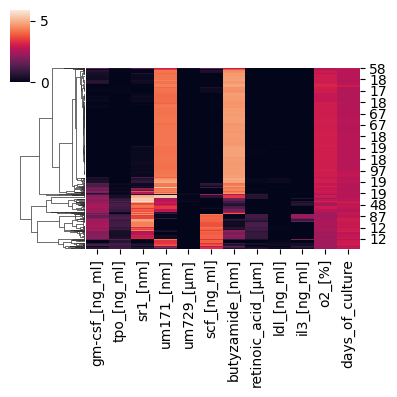

In [212]:
sns.clustermap(np.log1p(filtered_loop1_mgk.loc[:, protocol_cols]), 
              row_cluster=True, 
              col_cluster=False, 
              figsize=(4,4))

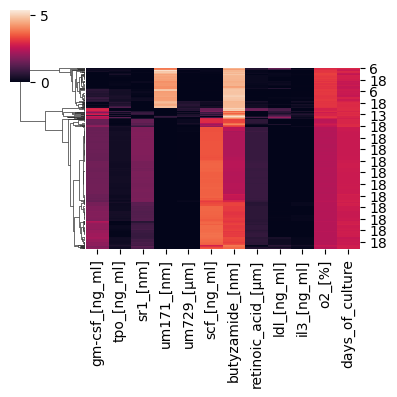

In [213]:
sns.clustermap(np.log1p(filtered_loop2_mgk.loc[:, protocol_cols]), 
              row_cluster=True, 
              col_cluster=False, 
              figsize=(4,4))

## EryPro

In [165]:
# sns.clustermap(np.log1p(erypro_loop1.loc[:, protocol_cols]), 
#               row_cluster=True, 
#               col_cluster=False, 
#               figsize=(4,4))

In [166]:
# sns.clustermap(np.log1p(erypro_loop2.loc[:, protocol_cols]), 
#               row_cluster=True, 
#               col_cluster=False, 
#               figsize=(4,4))

In [167]:
# del adata

## Check diversity

In [232]:
filtered_loop1_mgk_values = np.log1p(filtered_loop1_mgk.loc[:, protocol_cols]).values

In [233]:
filtered_loop2_mgk_values = np.log1p(filtered_loop2_mgk.loc[:, protocol_cols]).values

In [234]:
dist_mat_l1 = ((filtered_loop1_mgk_values[:, None] - filtered_loop1_mgk_values[None, :])**2).mean(-1)

In [235]:
dist_mat_l2 = ((filtered_loop2_mgk_values[:, None] - filtered_loop2_mgk_values[None, :])**2).mean(-1)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance m

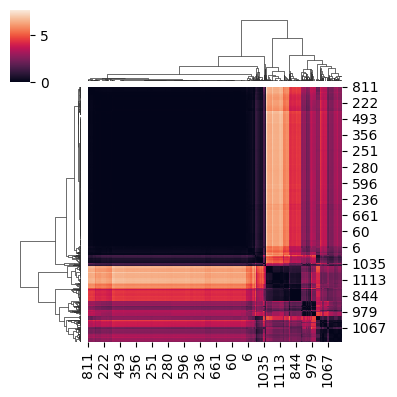

In [238]:
sns.clustermap(dist_mat_l1, 
              row_cluster=True, 
              col_cluster=True, 
              figsize=(4,4))

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance m

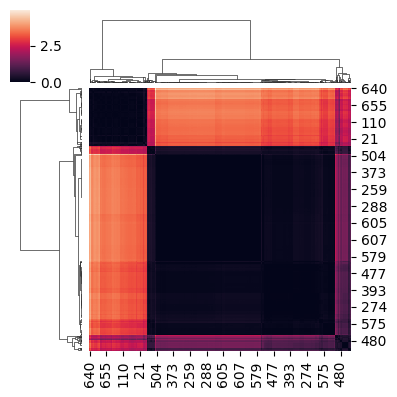

In [239]:
sns.clustermap(dist_mat_l2, 
              row_cluster=True, 
              col_cluster=True, 
              figsize=(4,4))